In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import sklearn as sklearn

# 경고 메시지를 숨기는 설정
import warnings
warnings.filterwarnings("ignore")


In [ ]:
titanic = sns.load_dataset('titanic')


In [ ]:
# 영상 예제와 같은 train/test 데이터를 각각 불러온다.
# train 데이터는 모델이 공부하는 데이터, test 데이터는 모델 성능을 시험하는 데이터
# 사실 그냥 3주차의 전처리 과정을 다시 반복하는거...
df_train = pd.read_csv("./data/titanic_train.csv")
df_test = pd.read_csv("./data/titanic_test.csv")

print(df_train.shape)
print(df_test.shape)

# 사용하지 않을 피처 제거해주기
# ticket, body, home.dest는 예측에 바로 쓰기 어렵고, cabin/name은 기본 모델에서는 일단 제외한다.
# 근데 name이랑 cabin을 그냥 버려도 되나?...
# 일단 기본 모델에서는 단순하게 제거하고, 뒤에서 의미 있는 정보만 뽑아서 다시 써보기로 한다.
df_train = df_train.drop(['name', 'ticket', 'body', 'cabin', 'home.dest'], axis=1)
df_test = df_test.drop(['name', 'ticket', 'body', 'cabin', 'home.dest'], axis=1)

# age 결측값을 train 데이터의 평균으로 대체
# 머신러닝 모델은 결측값 NaN을 그대로 학습하기 어렵기 때문에 대표값으로 채운다.
# 여기서는 영상 흐름을 따라가기 위해 가장 단순한 평균을 사용한다.
replace_mean = df_train[df_train['age'] > 0]['age'].mean()
df_train['age'] = df_train['age'].fillna(replace_mean)
df_test['age'] = df_test['age'].fillna(replace_mean)

# embarked 결측값을 train 데이터의 최빈값으로 대체
# 항구처럼 범주형 데이터는 평균을 낼 수 없어서 가장 많이 나온 값으로 ㄱㄱ
embarked_mode = df_train['embarked'].value_counts().index[0]
df_train['embarked'] = df_train['embarked'].fillna(embarked_mode)
df_test['embarked'] = df_test['embarked'].fillna(embarked_mode)

# 원-핫 인코딩을 위해 train/test를 합친 뒤 다시 분리
# sex, embarked 같은 문자열 컬럼을 모델이 이해할 수 있는 0/1 숫자 컬럼으로 바꾼다.
# 왜냐면 train/test에 있는 범주가 다르면 더미 컬럼 개수가 달라질 수 있어서, 같은 기준으로 인코딩하려고 합친다.
whole_df = pd.concat([df_train, df_test])
train_idx_num = len(df_train)

whole_df_encoded = pd.get_dummies(whole_df)

# 합쳐서 인코딩한 데이터를 다시 원래 train/test 크기대로 나눈다.
df_train = whole_df_encoded[:train_idx_num]
df_test = whole_df_encoded[train_idx_num:]

# 데이터를 학습 데이터셋, 테스트 데이터셋으로 분리
# x는 입력 변수들, y는 모델이 맞혀야 하는 정답 
x_train = df_train.loc[:, df_train.columns != 'survived'].values
y_train = df_train['survived'].values

x_test = df_test.loc[:, df_test.columns != 'survived'].values
y_test = df_test['survived'].values


(916, 13)
(393, 13)


In [ ]:
#이제 한번 확인해보자 
df_train.head()


,pclass,survived,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,2,1,13.000000,0,1,19.5000,True,False,False,False,True
1,2,1,4.000000,1,1,23.0000,True,False,False,False,True
2,2,1,30.000000,1,0,13.8583,True,False,True,False,False
3,3,0,30.231444,0,0,7.7250,False,True,False,True,False
4,3,1,22.000000,0,0,7.7250,True,False,False,True,False


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# LogisticRegression은 생존/사망처럼 0과 1을 예측하는 이진 분류 모델이다.
# 여기서는 생존할 확률을 계산한 뒤 기준값을 넘으면 1, 아니면 0으로 분류한다.
lr = LogisticRegression(random_state=0)
lr.fit(x_train, y_train)

# predict는 최종 예측값 0/1을 반환한다.
y_pred = lr.predict(x_test)

# predict_proba는 각 클래스가 될 확률을 반환한다.
# [:, 1]은 survived=1, 즉 생존일 확률만 가져온다는 뜻이다.
y_pred_probability = lr.predict_proba(x_test)[:, 1]

# accuracy: 전체 중 맞힌 비율
# precision: 생존이라고 예측한 사람 중 실제 생존자의 비율
# recall: 실제 생존자 중 모델이 생존으로 찾아낸 비율
# f1: precision과 recall의 융합한...둘다 합친 점수, 사실 더 제일 중요한 점수일듯
print("accuracy: %.2f" % accuracy_score(y_test, y_pred))
print("Precision : %.3f" % precision_score(y_test, y_pred))
print("Recall : %.3f" % recall_score(y_test, y_pred))
print("F1 : %.3f" % f1_score(y_test, y_pred))


accuracy: 0.80
Precision : 0.756
Recall : 0.673
F1 : 0.712


In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix는 모델이 무엇을 맞히고 무엇을 틀렸는지 보여주는 표
# accuracy만 보면 80%라 좋아 보이는데, 실제로 어떤 종류의 실수를 하는지는 알기 어려우니깐
# 그래서 생존자를 사망으로 틀린 경우(FN)와 사망자를 생존으로 틀린 경우(FP)를 따로 확인한다.
# [[TN, FP], [FN, TP]] 구조로 나온다.
# TN: 실제 사망을 사망으로 맞힘, FP: 실제 사망을 생존으로 틀림
# FN: 실제 생존을 사망으로 틀림, TP: 실제 생존을 생존으로 맞힘
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)


[[214  32]
 [ 48  99]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree는 조건을 계속 나누면서 예측하는 분류 모델이다.
# 예: 성별이 female인가? 객실 등급이 1등석인가? 같은 규칙을 트리 형태로 보여줌
dtc_basic = DecisionTreeClassifier(random_state=0)
dtc_basic.fit(x_train, y_train)

# 로지스틱 회귀 결과와 섞이지 않도록 Decision Tree 전용 변수명으로 저장한다.
y_pred_dtc_basic = dtc_basic.predict(x_test)
y_pred_probability_dtc_basic = dtc_basic.predict_proba(x_test)[:, 1]

print('accuracy: %2f' % accuracy_score(y_test, y_pred_dtc_basic))


accuracy: 0.750636


AUC : 0.742


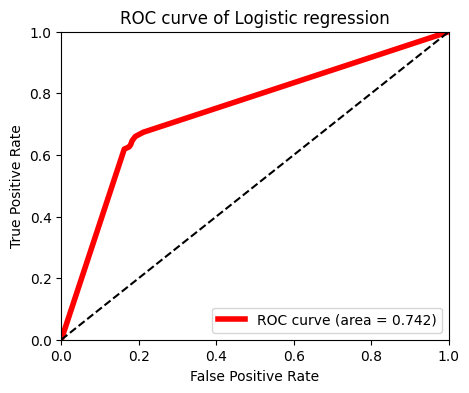

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve는 예측 확률의 기준값을 바꿔가며 분류 성능을 보는 그래프다.
# 쉽게 생각해서 모델이 생존자와 사망자를 얼마나 잘 구분하는지 한 숫자로 요약한 값
# 근데 왜 accuracy 말고 AUC까지 볼까?
# threshold를 0.5 하나로 고정하면 모델의 전체적인 분류 능력을 못보기 때문에... 
# AUC는 ROC Curve 아래 면적으로, 0.5면 사실상 그냥 찍는거고.. 1에 가까우면 유의미함
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_probability)
roc_auc = roc_auc_score(y_test, y_pred_probability)
print("AUC : %.3f" % roc_auc)

plt.rcParams['figure.figsize'] = [5, 4]
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label='ROC curve (area = %0.3f)' % roc_auc,
    color='red',
    linewidth=4.0
)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve of Logistic regression')
plt.legend(loc='lower right')
plt.show()


accuracy: 0.75
Precision : 0.672
Recall : 0.626
F1 : 0.648
AUC : 0.736


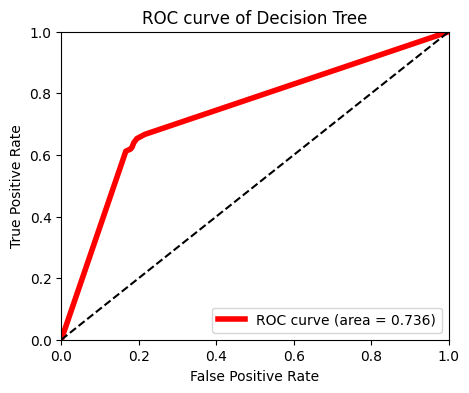

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 같은 데이터로 Decision Tree 모델을 다시 학습해서 Logistic Regression과 성능을 비교한다.
# 로지스틱 회귀 하나만 보면 이 성능이 좋은 건지 판단하기 어렵다.
# 그래서 해석 방식이 다른 Decision Tree를 같이 돌려 비교 기준을 만든다.
dtc = DecisionTreeClassifier(random_state=0)
dtc.fit(x_train, y_train)

y_pred_dtc = dtc.predict(x_test)
y_pred_probability_dtc = dtc.predict_proba(x_test)[:, 1]

print("accuracy: %.2f" % accuracy_score(y_test, y_pred_dtc))
print("Precision : %.3f" % precision_score(y_test, y_pred_dtc))
print("Recall : %.3f" % recall_score(y_test, y_pred_dtc))
print("F1 : %.3f" % f1_score(y_test, y_pred_dtc))

# Decision Tree의 예측 확률로 ROC/AUC를 계산한다.
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_probability_dtc)
roc_auc_dtc = roc_auc_score(y_test, y_pred_probability_dtc)
print("AUC : %.3f" % roc_auc_dtc)

plt.rcParams['figure.figsize'] = [5, 4]
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label='ROC curve (area = %0.3f)' % roc_auc_dtc,
    color='red',
    linewidth=4.0
)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve of Decision Tree')
plt.legend(loc='lower right')
plt.show()

#왜 이건 아까보다 auc가 낮게 나왔을까?
#먼저 Decision Tree는 훈련 데이터에 너무 딱 맞게 학습하는 경향이 있어서,
#어느정도의 과적합이 일어났다고 볼 수 있고...
#연속적인 확률보다
#조건이기 때문에 몇 개 값으로 뚝뚝 끊긴다는 단점이 존재함

In [17]:
# 피처 엔지니어링을 위해 원본 데이터를 다시 불러온다.
# 이번에는 name, cabin을 제거하지 않고 의미 있는 정보로 가공해서 사용한다.
df_train_fe = pd.read_csv("./data/titanic_train.csv")
df_test_fe = pd.read_csv("./data/titanic_test.csv")

# 피처 엔지니어링에서 사용할 name, cabin은 남기고 ticket/body/home.dest만 제거한다.
df_train_fe = df_train_fe.drop(['ticket', 'body', 'home.dest'], axis=1)
df_test_fe = df_test_fe.drop(['ticket', 'body', 'home.dest'], axis=1)

# 결측치 처리 방식은 기본 모델과 동일하게 맞춘다.
replace_mean = df_train_fe[df_train_fe['age'] > 0]['age'].mean()
df_train_fe['age'] = df_train_fe['age'].fillna(replace_mean)
df_test_fe['age'] = df_test_fe['age'].fillna(replace_mean)

embarked_mode = df_train_fe['embarked'].value_counts().index[0]
df_train_fe['embarked'] = df_train_fe['embarked'].fillna(embarked_mode)
df_test_fe['embarked'] = df_test_fe['embarked'].fillna(embarked_mode)

# train/test를 합쳐 같은 기준으로 cabin, name을 가공한다.
whole_df_fe = pd.concat([df_train_fe, df_test_fe])
train_idx_num_fe = len(df_train_fe)

whole_df_fe.head()


,pclass,survived,name,sex,age,sibsp,parch,fare,cabin,embarked
0,2,1,"Mellinger, Miss. Madeleine Violet",female,13.000000,0,1,19.5000,NaN,S
1,2,1,"Wells, Miss. Joan",female,4.000000,1,1,23.0000,NaN,S
2,2,1,"Duran y More, Miss. Florentina",female,30.000000,1,0,13.8583,NaN,C
3,3,0,"Scanlan, Mr. James",male,30.231444,0,0,7.7250,NaN,Q
4,3,1,"Bradley, Miss. Bridget Delia",female,22.000000,0,0,7.7250,NaN,Q


cabin
C23 C25 C27        6
B57 B59 B63 B66    5
G6                 5
F4                 4
B96 B98            4
F33                4
C78                4
D                  4
F2                 4
C22 C26            4
Name: count, dtype: int64


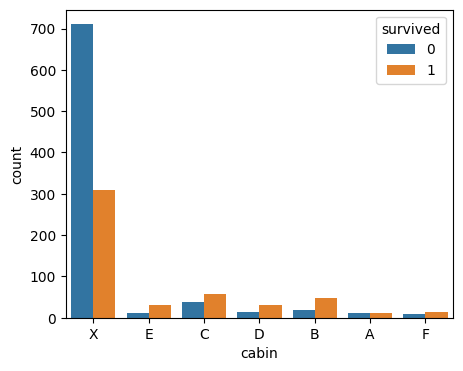

In [ ]:
# cabin은 객실 번호 전체보다 첫 글자만 사용하는 것이 더 단순..
# 첫 글자만 쓰면 대략적인 객실 구역 정보로 압축해서 볼 수 있다.
# 예: C85 -> C, B57 -> B. 첫 글자는 객실 구역 정보
print(whole_df_fe['cabin'].value_counts()[:10])

# cabin 결측값은 X로 채우고, 첫 글자만 남긴다.
whole_df_fe['cabin'] = whole_df_fe['cabin'].fillna('X')
whole_df_fe['cabin'] = whole_df_fe['cabin'].apply(lambda x: x[0])
whole_df_fe['cabin'] = whole_df_fe['cabin'].replace({'G': 'X', 'T': 'X'})

# cabin 구역별 생존/사망 분포를 시각화해서 예측에 쓸 만한 정보인지 확인해주기
ax = sns.countplot(x='cabin', hue='survived', data=whole_df_fe)
plt.show()


In [19]:
# name 컬럼 자체는 길고 복잡하지만, Mr/Mrs/Miss/Master 같은 호칭은 의미가 있다.
# 이름이 생존과 무슨 상관이지? 라고 생각할 수 있는데,
# 실제 이름보다 호칭이 성별/나이/사회적 지위 정보를 담고 있을 가능성이 있다.
# 호칭은 성별, 나이, 사회적 지위와 연결될 수 있어서 생존 예측에 도움이 될 수 있다.
name_grade = whole_df_fe['name'].apply(lambda x: x.split(',', 1)[1].split('.')[0])
name_grade = name_grade.unique().tolist()
print(name_grade)


[' Miss', ' Mr', ' Master', ' Mrs', ' Dr', ' Mlle', ' Col', ' Rev', ' Ms', ' Mme', ' Sir', ' the Countess', ' Dona', ' Jonkheer', ' Lady', ' Major', ' Don', ' Capt']


In [ ]:
# 호칭을 세부 문자열 그대로 쓰지 않고 A~G 그룹으로 묶는다.
# 호칭을 전부 따로 두면 희귀한 호칭은 데이터가 너무 적어서 불안정할 수 있다.
# 그래서 비슷한 의미를 가진 호칭끼리 묶어서 단순화
grade_dict = {
    'A': ['Rev', 'Col', 'Major', 'Dr', 'Capt', 'Sir'],
    'B': ['Ms', 'Mme', 'Mrs', 'Dona'], #기혼 여성/여성 호칭
    'C': ['Jonkheer', 'the Countess'],
    'D': ['Mr', 'Don'],
    'E': ['Master'], #젊은 남자아이 호칭
    'F': ['Miss', 'Mlle', 'Lady']
}

def give_grade(x):
    grade = x.split(', ', 1)[1].split('.')[0]
    for key, value in grade_dict.items():
        for title in value:
            if grade == title:
                return key
    return 'G'

# name 문자열을 호칭 그룹 A~G로 바꾼다.
whole_df_fe['name'] = whole_df_fe['name'].apply(lambda x: give_grade(x))
print(whole_df_fe['name'].value_counts())


name
D    758
F    263
B    201
E     61
A     24
C      2
Name: count, dtype: int64


In [21]:
# 가공한 cabin/name까지 포함해서 다시 원-핫 인코딩한다.
# 이후 train/test를 원래 길이 기준으로 다시 나눈다.
whole_df_encoded_fe = pd.get_dummies(whole_df_fe)
df_train_fe = whole_df_encoded_fe[:train_idx_num_fe]
df_test_fe = whole_df_encoded_fe[train_idx_num_fe:]

# 피처 엔지니어링 이후 모델에 들어갈 컬럼 구조를 확인한다.
df_train_fe.head()


,pclass,survived,age,sibsp,parch,fare,name_A,name_B,name_C,name_D,...,cabin_A,cabin_B,cabin_C,cabin_D,cabin_E,cabin_F,cabin_X,embarked_C,embarked_Q,embarked_S
0,2,1,13.000000,0,1,19.5000,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,1,4.000000,1,1,23.0000,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,2,1,30.000000,1,0,13.8583,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False
3,3,0,30.231444,0,0,7.7250,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False
4,3,1,22.000000,0,0,7.7250,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


accuracy: 0.79
Precision : 0.736
Recall : 0.701
F1 : 0.718
AUC : 0.852


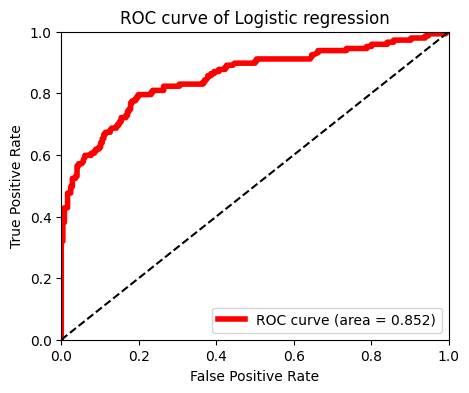

In [ ]:
# 피처 엔지니어링으로 만든 데이터셋에서 x/y를 다시 나눈다.
x_train_fe = df_train_fe.loc[:, df_train_fe.columns != 'survived'].values
y_train_fe = df_train_fe['survived'].values

x_test_fe = df_test_fe.loc[:, df_test_fe.columns != 'survived'].values
y_test_fe = df_test_fe['survived'].values

# name, cabin 가공 피처를 추가한 상태로 Logistic Regression을 다시 학습한다.
lr_fe = LogisticRegression(random_state=0)
lr_fe.fit(x_train_fe, y_train_fe)

y_pred_fe = lr_fe.predict(x_test_fe)
y_pred_probability_fe = lr_fe.predict_proba(x_test_fe)[:, 1]

# 기본 모델과 비교해서 피처 엔지니어링이 성능에 도움이 되었는지 확인한다.
# 새 피처를 만들었다고 무조건 좋아지는 건 아니다.
# 그래서 accuracy뿐 아니라 precision/recall/f1/AUC를 다시 확인해서 실제로 도움이 됐는지 비교한다.
print("accuracy: %.2f" % accuracy_score(y_test_fe, y_pred_fe))
print("Precision : %.3f" % precision_score(y_test_fe, y_pred_fe))
print("Recall : %.3f" % recall_score(y_test_fe, y_pred_fe))
print("F1 : %.3f" % f1_score(y_test_fe, y_pred_fe))

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test_fe, y_pred_probability_fe)
roc_auc_fe = roc_auc_score(y_test_fe, y_pred_probability_fe)
print("AUC : %.3f" % roc_auc_fe)

plt.rcParams['figure.figsize'] = [5, 4]
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label='ROC curve (area = %0.3f)' % roc_auc_fe,
    color='red',
    linewidth=4.0
)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve of Logistic regression')
plt.legend(loc='lower right')
plt.show()

#꽤나 많이 상승했다!
#결국 name과 cabin의 정보가 들어가면서
#생존자와 사망자를 더 잘 구분하게 되어 AUC가 크게 상승했음

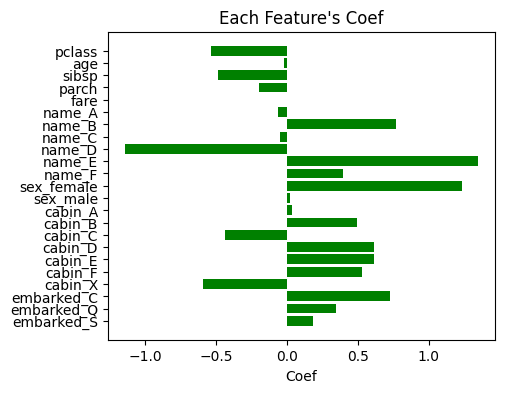

In [ ]:
# Logistic Regression의 계수는 각 피처가 생존 예측에 어느 방향으로 작용했는지 보여준다.
# 양수면 survived=1, 즉 생존 쪽으로 영향을 주고, 음수면 사망 쪽으로 영향을 준다고 볼 수 있다.
cols = df_train_fe.columns.tolist()
cols.remove('survived')
y_pos = np.arange(len(cols))

plt.rcParams['figure.figsize'] = [5, 4]
fig, ax = plt.subplots()
ax.barh(y_pos, lr_fe.coef_[0], align='center', color='green', ecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(cols)
ax.invert_yaxis()
ax.set_xlabel('Coef')
ax.set_title("Each Feature's Coef")
plt.show()

#막대 길이가 김 == 모델이 그 변수를 강하게 사용함
#막대가 0에 가까움 == 영향이 작음
#우리가 아는 SHAP랑 비슷한 개념이긴 한데, 
#SHAP은 모델이 예측할 때 각 피처가 어떻게 기여했는지 샘플별로 보여주는 방식이라면,
#이건 모델이 전체적으로 각 피처를 어떻게 사용했는지 보여주는 방식


[0.8235108729908603, 0.8803061287723863, 0.8671913580246913, 0.8798444976076555, 0.8355113636363636]


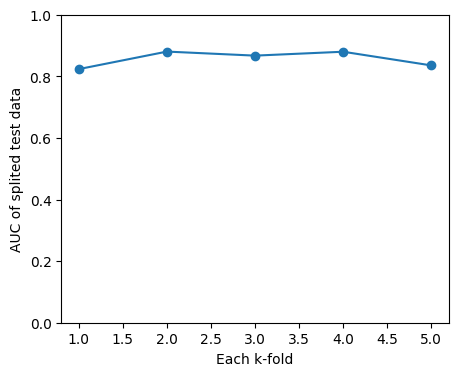

In [24]:
from sklearn.model_selection import KFold

# K-fold 교차검증은 데이터를 여러 번 나눠서 모델 성능이 안정적인지 확인하는 방법이다.
# 한 번 나눈 test set에서만 잘 나온 걸 수도 있지 않을까?
# 그래서 여러 번 나눠 평균적으로도 비슷한 성능이 나오는지 확인한다.
# 한 번의 train/test 분할 결과만 보면 우연히 좋거나 나쁠 수 있기 때문이다.
k = 5
cv = KFold(k, shuffle=True, random_state=0)
auc_history = []

for i, (train_data_row, test_data_row) in enumerate(cv.split(whole_df_encoded_fe)):
    df_train_fold = whole_df_encoded_fe.iloc[train_data_row]
    df_test_fold = whole_df_encoded_fe.iloc[test_data_row]

    splited_x_train = df_train_fold.loc[:, df_train_fold.columns != 'survived'].values
    splited_y_train = df_train_fold['survived'].values
    splited_x_test = df_test_fold.loc[:, df_test_fold.columns != 'survived'].values
    splited_y_test = df_test_fold['survived'].values

    lr_fold = LogisticRegression(random_state=0)
    lr_fold.fit(splited_x_train, splited_y_train)
    y_pred_probability_fold = lr_fold.predict_proba(splited_x_test)[:, 1]

    # 각 fold마다 AUC를 계산해서 성능이 얼마나 흔들리는지 기록한다.
    roc_auc_fold = roc_auc_score(splited_y_test, y_pred_probability_fold)
    auc_history.append(roc_auc_fold)

print(auc_history)

plt.rcParams['figure.figsize'] = [5, 4]
plt.xlabel('Each k-fold')
plt.ylabel('AUC of splited test data')
plt.plot(range(1, k + 1), auc_history, marker='o')
plt.ylim([0.0, 1.0])
plt.show()


In [ ]:
# 가족 관련 피처 추가 실험
# sibsp: 함께 탄 형제/배우자 수, parch: 함께 탄 부모/자녀 수
# 둘을 합치면 승객이 혼자 탔는지, 가족 단위로 탔는지 더 직접적으로 표현할 수 있다.
whole_df_family = whole_df_fe.copy()

# 자기 자신까지 포함한 가족 규모
whole_df_family['family_size'] = whole_df_family['sibsp'] + whole_df_family['parch'] + 1

# 혼자 탔으면 1, 가족/동행이 있으면 0
whole_df_family['is_alone'] = (whole_df_family['family_size'] == 1).astype(int)

# 가족 규모가 너무 세분화되면 불안정할 수 있으니 대략적인 그룹도 만들어본다.
def family_group(size):
    if size == 1:
        return 'alone'
    elif size <= 4:
        return 'small'
    else:
        return 'large'

whole_df_family['family_group'] = whole_df_family['family_size'].apply(family_group)

# 새로 만든 family_group은 문자열이므로 다시 원-핫 인코딩
whole_df_encoded_family = pd.get_dummies(whole_df_family)

df_train_family = whole_df_encoded_family[:train_idx_num_fe]
df_test_family = whole_df_encoded_family[train_idx_num_fe:]

x_train_family = df_train_family.loc[:, df_train_family.columns != 'survived'].values
y_train_family = df_train_family['survived'].values

x_test_family = df_test_family.loc[:, df_test_family.columns != 'survived'].values
y_test_family = df_test_family['survived'].values

lr_family = LogisticRegression(random_state=0)
lr_family.fit(x_train_family, y_train_family)

y_pred_family = lr_family.predict(x_test_family)
y_pred_probability_family = lr_family.predict_proba(x_test_family)[:, 1]

print("accuracy: %.2f" % accuracy_score(y_test_family, y_pred_family))
print("Precision : %.3f" % precision_score(y_test_family, y_pred_family))
print("Recall : %.3f" % recall_score(y_test_family, y_pred_family))
print("F1 : %.3f" % f1_score(y_test_family, y_pred_family))
print("AUC : %.3f" % roc_auc_score(y_test_family, y_pred_probability_family))

# 기존 피처 엔지니어링 모델과 AUC를 바로 비교한다.
print("기존 FE AUC : %.3f" % roc_auc_fe)
print("가족 피처 추가 AUC : %.3f" % roc_auc_score(y_test_family, y_pred_probability_family))

#ㅋㅋ 딱히 좋아지지도 나빠지지도 않았음 

accuracy: 0.81
Precision : 0.752
Recall : 0.721
F1 : 0.736
AUC : 0.854
기존 FE AUC : 0.852
가족 피처 추가 AUC : 0.854


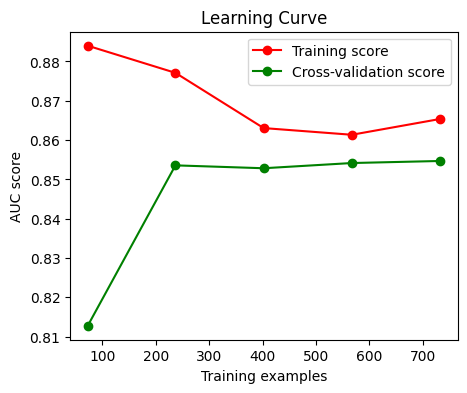

In [31]:
from sklearn.model_selection import learning_curve

# Learning Curve는 학습 데이터 양이 늘어날 때 train 성능과 검증 성능이 어떻게 변하는지 보여준다.
# 데이터가 더 많아지면 성능이 더 좋아질까? 아니면 모델 자체가 한계일까?
# 이런 질문을 확인하기 위해 학습 데이터 크기별 성능 변화를 본다.
# 과적합인지, 데이터가 더 필요한지, 모델이 너무 단순한지 판단할 때 참고한다.
train_sizes, train_scores, test_scores = learning_curve(
    lr_fe,
    x_train_fe,
    y_train_fe,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.rcParams['figure.figsize'] = [5, 4]
plt.plot(train_sizes, train_scores_mean, 'o-', color='red', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('AUC score')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.show()

#보면 이건 초반에 모델이 적은 학습 데이터에는 잘 맞지만, 
#새로운 데이터에는 많이 틀려 성능도 안좋고 과적합 경향이 있음
#하지만 이후에는 평행상태에 접어들면서, 어느정도 한계에 도달했다고 볼수있음.

#그러면 어떻게 하면 더 올릴 수 있을까?
#음... 다른 가족관련 키워드를 추가로 엔지니어링 해봐도 되고
#다른 모델을 써봐도 되고
#파라미터 튜닝을 해도 될거같긴 하다
#나이를 더 세부적으로 범주화해서 써봐도 될수도